# COURSE: A deep understanding of deep learning
## SECTION: Gradient descent
### LECTURE: Gradient descent in 1D
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [1]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # sets the format in vectors instead of pixels.

# from Ipython import display
# display.set_matplotlib_formats('svg')

# Gradient descent in 1D

In [2]:
# function (as a function)
def fx(x):
  return 3*x**2 - 3*x + 4 # function is hardcoded

# derivative function
def deriv(x):
  return 6*x - 3 # derivative is hardcoded

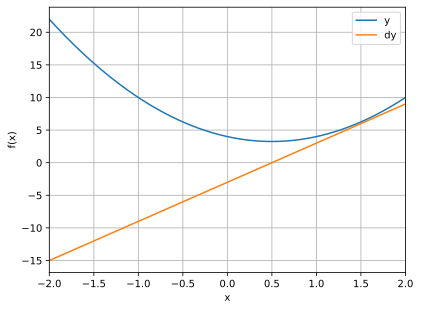

In [3]:
# plot the function and its derivative

# define a range for x
x = np.linspace(-2,2,2001)

# plotting
plt.plot(x,fx(x), x,deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y','dy'])
plt.show()

### every time the below code is run the he starting point will be different because of random initialization

### but the result will be closer to the local minimum of the function in this case its 0.5

In [4]:
# random starting point
localmin = np.random.choice(x,1)
print(localmin)

# learning parameters
learning_rate = .01
training_epochs = 100

# run through training , this implements the gradient descent algorithm
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad

localmin

[-0.02]


array([0.49893147])

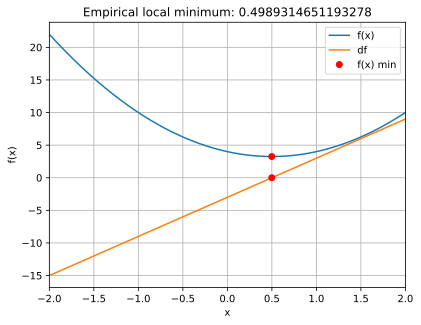

In [5]:
# plot the results

plt.plot(x,fx(x), x,deriv(x))
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin[0])
plt.show()

# Store the model parameters and outputs on each iteration

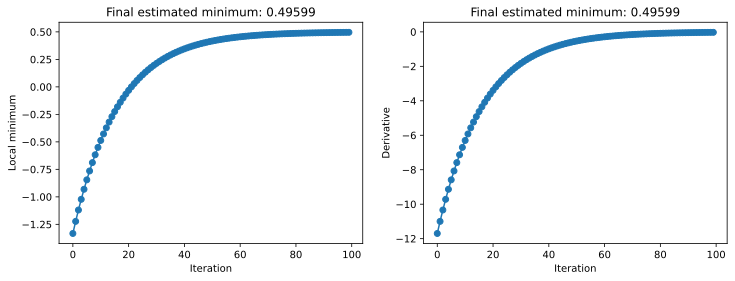

In [18]:
# random starting point
localmin = np.random.choice(x,1)

# learning parameters
learning_rate = 0.01 # if learnning rate is small more training epoch is needed.
training_epochs = 100

# run through training and store all the results
modelparams = np.zeros((training_epochs,2))
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad
  modelparams[i,0] = localmin[0]
  modelparams[i,1] = grad[0]
  # plot the gradient over iterations

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
  ax[i].plot(modelparams[:,i],'o-')
  ax[i].set_xlabel('Iteration')
  ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()


# Additional explorations

In [8]:
# 1) Most often in DL, the model trains for a set number of iterations, which is what we do here. But there are other ways
#    of defining how long the training lasts. Modify the code so that training ends when the derivative is smaller than 
#    some threshold, e.g., 0.1. Make sure your code is robust for negative derivatives.
# 
# 2) Does this change to the code produce a more accurate result? What if you change the stopping threshold?
# 
# 3) Can you think of any potential problems that might arise when the stopping criterion is based on the derivative 
#    instead of a specified number of training epochs?
# 

start point is : [-1.096]
75


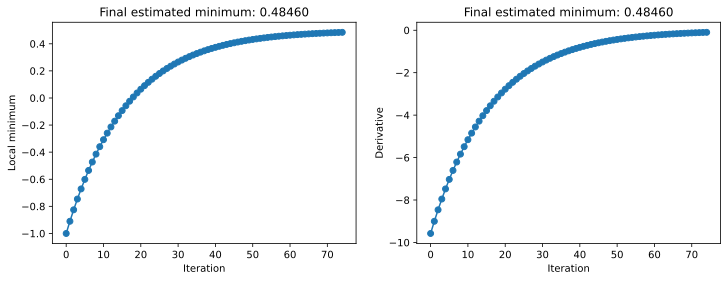

In [100]:

# 1) Modify the code so that training ends when the derivative is smaller than some threshold.
# e.g., 0.1. Make sure your code is robust for negative derivatives.
# random starting point
localmin = np.random.choice(x,1)
print("start point is :",localmin)

# learning parameters
learning_rate = 0.01 # if learnning rate is small more training epoch is needed.
training_epochs = 100

# run through training and store all the results
modelparams = np.zeros((training_epochs,2))
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad
  modelparams[i,0] = localmin[0]
  modelparams[i,1] = grad[0]
  if np.abs(grad) < 0.1: # stopping criterion based
    break
  # plot the gradient over iterations

trained_epochs = i+1
print(trained_epochs)
trainedmodelparams = modelparams[:trained_epochs]

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
  ax[i].plot(trainedmodelparams[:,i],'o-')
  ax[i].set_xlabel('Iteration')
  ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()


start point is : [-1.364]
78


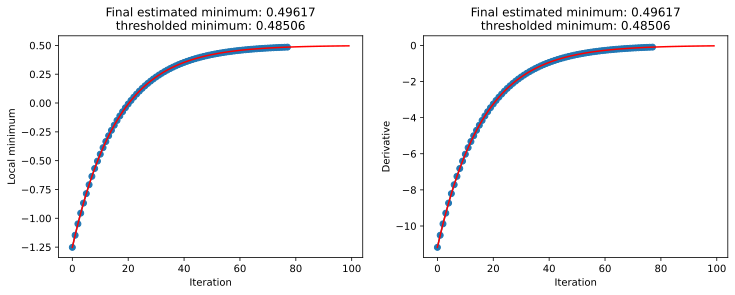

In [110]:
# 2) Does this change to the code produce a more accurate result? What if you change the stopping threshold?

# random starting point
localmin = np.random.choice(x,1)
print("start point is :",localmin)

# learning parameters
learning_rate = 0.01 # if learnning rate is small more training epoch is needed.
training_epochs = 100

# run through training and store all the results
thflg = 0
modelparams = np.zeros((training_epochs,2))
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad
  modelparams[i,0] = localmin[0]
  modelparams[i,1] = grad[0]
  if np.abs(grad) < 0.1: # stopping criterion based
    if not(thflg):
      thd_epochs = i+1
      thd_localmin = localmin
      thflg = 1

  # plot the gradient over iterations
print(thd_epochs)
thd_modelparams = modelparams[:thd_epochs]

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
  ax[i].plot(thd_modelparams[:,i],'o-') # the significance of ',' in thd_modelparams[:,i] is that it separates the row index from the column index
  ax[i].plot(modelparams[:,i],'r-')
  ax[i].set_xlabel('Iteration')
  ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}\nthresholded minimum: {thd_localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()


In [ ]:
# 3) Can you think of any potential problems that might arise when the stopping criterion is based on the derivative 
#    instead of a specified number of training epochs?


# if the threshold is set too low, it may stop prematurely and not allow the model to fully converge. 
# This can lead to suboptimal performance or even overfitting. 
# On the other hand, if the threshold is set too high, the algorithm may take a long time to converge.

# Additionally, the derivative-based stopping criterion may not work well for non-convex functions 
# where there may be multiple local minima. 
# In such cases, using a fixed threshold based on the derivative may miss important features of the function.


